# Analyzing New York Times Coverage of Mexico
**Project Overview:** This notebook explores and analyzes a dataset of NYT articles covering Mexico. We will perform Exploratory Data Analysis (EDA), extract text features, and build an NLP pipeline to analyze sentiment and key themes.

## Exploratory Data Analysis

### Project Objectives

**1. Feature Engineering:**
Extract structural features from the raw text to quantify journalistic style, including:
*   Word count and sentence count per article
*   Total character count
*   Average word length

**2. Data Visualization:**
Develop visualizations to uncover dataset trends and distributions, focusing on:
*   Article frequency over time (monthly distribution)
*   The distribution of article lengths to identify reporting formats
*   Top contributing authors and reporting distribution

## **Step 1: Load Data & Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
# Ensure necessary NLTK resources are downloaded
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
# Optional: Mount Google Drive if running in Google Colab with data stored in Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Step 2: Text Feature Analysis & Article Statistics**

In [3]:
# 1. Load Dataset
# Update this file_path to wherever you store the dataset locally or in your own Drive
file_path = 'sample_data.csv'
df = pd.read_csv(file_path)

# 2. Convert Date and Create Month Column
# We remove 'timezone' info to avoid errors during plotting
df['Publication Date'] = pd.to_datetime(df['Publication Date']).dt.tz_localize(None)
df['Month'] = df['Publication Date'].dt.to_period('M').astype(str) # Simpler format for sorting

# 3. Data Integrity Check
print("--- Dataset Overview ---")
df.info()

# 4. Basic Inspection
print("\n--- First 5 Rows ---")
display(df[['Title', 'Author', 'Publication Date']].head())

--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Article#              86 non-null     int64         
 1   Title                 86 non-null     object        
 2   Publication Date      86 non-null     datetime64[ns]
 3   Time                  86 non-null     object        
 4   Author                86 non-null     object        
 5   Summary               86 non-null     object        
 6   URL                   86 non-null     object        
 7   Full Article Content  86 non-null     object        
 8   Month                 86 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 6.2+ KB

--- First 5 Rows ---


,Title,Author,Publication Date
0,Mexican Troops Kill 19 Suspected of Being Cart...,By Simon Romero and Emiliano Rodríguez Mega,2024-10-23
1,Mexico’s Ex-Security Chief Sentenced to 38 Yea...,By Alan Feuer,2024-10-16
2,A Cartel Double-Cross Turns a Mexican State In...,"By Natalie Kitroeff, Paulina Villegas and Meri...",2024-10-08
3,"In Mexico, a Mayor Is Brutally Killed Just Day...",By Emiliano Rodríguez Mega,2024-10-07
4,Mexican Military Fatally Shoots Six Migrants,By Emiliano Rodríguez Mega and James Wagner,2024-10-03


In [4]:
import nltk

# Download necessary NLTK corpora and models for text processing
nltk.download('punkt')       # Basic tokenization
nltk.download('punkt_tab')   # Advanced sentence splitting
nltk.download('stopwords')   # Stopword removal
nltk.download('wordnet')     # Lemmatization

print("NLTK Resources Downloaded Successfully.")

NLTK Resources Downloaded Successfully.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



--- Statistical Summary of Text Features ---


,count,mean,std,min,25%,50%,75%,max
word_count,86.0,976.60,335.47,139.00,775.25,890.50,1241.75,1839.00
char_count,86.0,6009.36,2046.72,1149.00,4880.75,5540.00,7768.75,11419.00
sent_count,86.0,40.21,17.75,2.00,30.00,37.00,51.75,113.00
avg_word_len,86.0,6.18,0.28,5.68,6.07,6.17,6.26,8.27
avg_sent_len,86.0,25.89,6.37,12.06,23.09,25.06,28.02,69.50


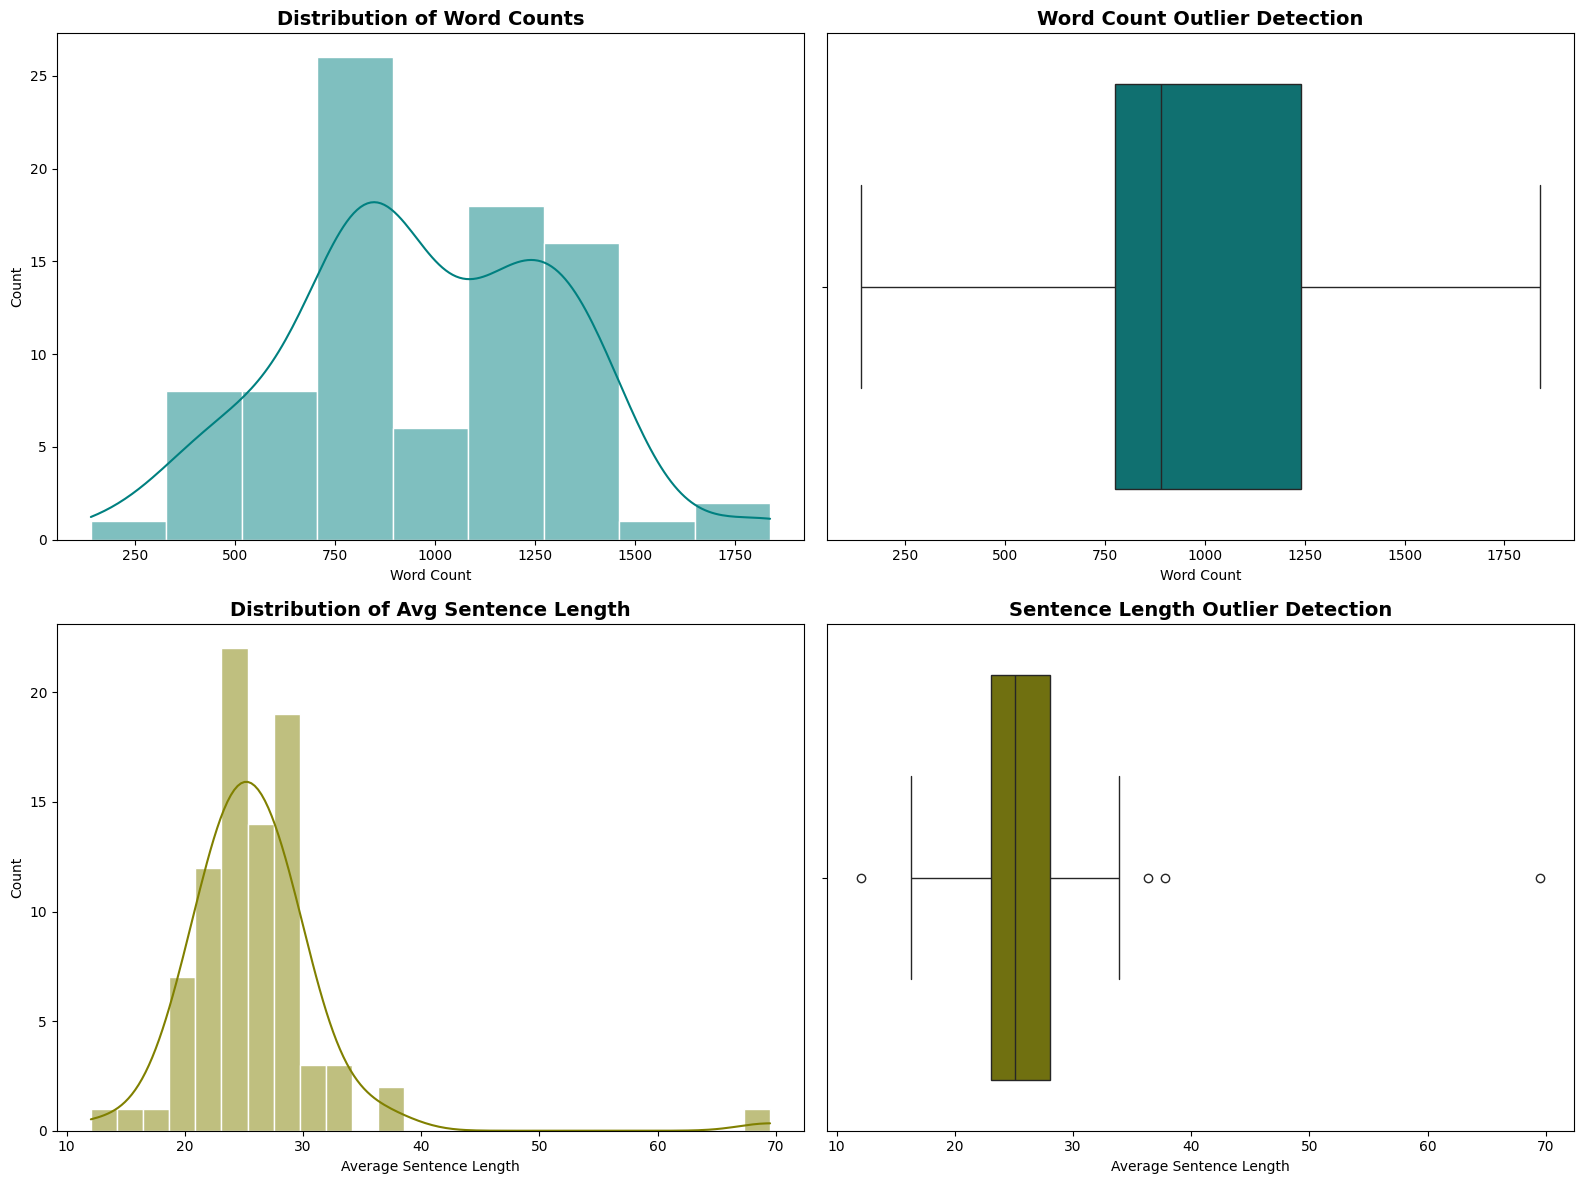

In [5]:
# --- Step 1: Feature Engineering ---
# Extract fundamental structural features from the text

# 1. Word Count
df['word_count'] = df['Full Article Content'].apply(lambda x: len(str(x).split()))

# 2. Character Count (includes spaces)
df['char_count'] = df['Full Article Content'].apply(lambda x: len(str(x)))

# 3. Sentence Count
df['sent_count'] = df['Full Article Content'].apply(lambda x: len(sent_tokenize(str(x))))

# 4. Average Word Length
df['avg_word_len'] = df['char_count'] / df['word_count']

# 5. Average Sentence Length
# Evaluates structural density of the journalistic text
df['avg_sent_len'] = df['word_count'] / df['sent_count']

print("\n--- Statistical Summary of Text Features ---")
display(df[['word_count', 'char_count', 'sent_count', 'avg_word_len', 'avg_sent_len']].describe().round(2).T)

# --- Step 2: Univariate Distribution Analysis ---
# Visualize distributions and detect potential outliers

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 1. Word Count Distribution (Histogram)
sns.histplot(df['word_count'], kde=True, color='teal', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Word Counts', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Word Count')

# 2. Word Count Outliers (Boxplot)
sns.boxplot(x=df['word_count'], color='teal', ax=axes[0, 1])
axes[0, 1].set_title('Word Count Outlier Detection', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Word Count')

# 3. Avg Sentence Length (Histogram)
sns.histplot(df['avg_sent_len'], kde=True, color='olive', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Avg Sentence Length', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Sentence Length')

# 4. Avg Sentence Length (Boxplot)
sns.boxplot(x=df['avg_sent_len'], color='olive', ax=axes[1, 1])
axes[1, 1].set_title('Sentence Length Outlier Detection', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Average Sentence Length')

plt.tight_layout()
plt.show()

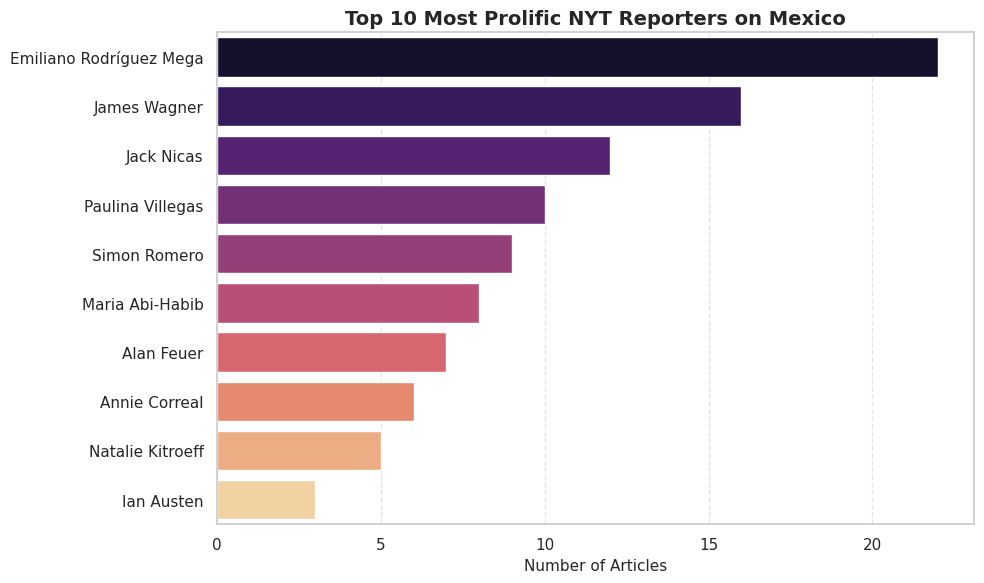

Total Unique Individual Contributors: 51


In [6]:
# Categorical Analysis (Individual Contributor Split) ---
import re

def split_authors(author_string):
    if pd.isna(author_string):
        return ["Unknown"]

    # Use regex to split by 'and', 'with', or commas
    # Example: "Simon Romero and Emiliano Rodriguez Mega" -> ["Simon Romero", "Emiliano Rodriguez Mega"]
    names = re.split(r'\s+and\s+|\s+with\s+|,\s*', str(author_string), flags=re.IGNORECASE)

    # Clean up whitespace and remove "By " if it's at the start
    return [name.replace('By ', '').strip() for name in names if name.strip()]

# 1. Create a copy to preserve the original dataframe structure
df_authors = df.copy()
df_authors['Author_List'] = df_authors['Author'].apply(split_authors)

# 2. "Explode" the list so each author gets a dedicated row
df_exploded = df_authors.explode('Author_List')

# 3. Calculate the top 10 most prolific authors
top_individual_authors = df_exploded['Author_List'].value_counts().head(10)

# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=top_individual_authors.values, y=top_individual_authors.index,
            palette='magma', hue=top_individual_authors.index, legend=False)

# Top 10 Individual Contributors (Split Bylines)
plt.title('Top 10 Most Prolific NYT Reporters on Mexico', fontweight='bold', fontsize=14)
plt.xlabel('Number of Articles', fontsize=11)
plt.ylabel("")
#plt.ylabel('Author Name', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Total Unique Individual Contributors: {df_exploded['Author_List'].nunique()}")

## **Step 3: Text Preprocessing & Normalization**

In [7]:
# --- Step 3: Text Preprocessing & Cleaning ---
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1. Setup Resources
nltk.download('stopwords')
nltk.download('wordnet')

# 2. Custom Stopword Filtering
# We include standard English words, journalism filler, AND primary subjects.
stop_words = set(stopwords.words('english'))

custom_noise = [
    'said', 'would', 'also', 'one', 'told', 'new', 'york', 'times', 'nyt',
    'year', 'years', 'last', 'first', 'mr', 'ms', 'mrs', 'respond', 'request',
    'comment'
]

# The primary_subjects were removed previously, which can hinder sentiment analysis
# focused on these subjects. We will no longer remove them as general stopwords.
# primary_subjects = [
#     'mexico', 'mexican', 'sheinbaum', 'claudia', 'lopez', 'obrador',
#     'andres', 'manuel', 'president', 'presidential', 'country', 'government',
#     'morena', 'party'
# ]

stop_words.update(custom_noise)
# stop_words.update(primary_subjects) # Do NOT remove primary subjects for sentiment analysis

def clean_text_final(text):
    # Handle Unicode (removes accents from names like 'López')
    text = unicodedata.normalize('NFKD', str(text)).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    # Lowercase and remove non-alphabet characters (punctuation, numbers)
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower().strip())

    # Lemmatization (grouping 'running'/'run', 'cities'/'city')
    lemmatizer = WordNetLemmatizer()
    words = text.split()

    # Filter out stopwords and words shorter than 3 characters
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]

    return " ".join(cleaned_words)

# 3. Apply Cleaning to create the 'clean_text' column
print("Cleaning text and retaining primary subject words for deeper sentiment analysis...")
df['clean_text'] = df['Full Article Content'].apply(clean_text_final)

# 4. Quick Verification
print("\n--- Original vs Cleaned Sample ---")
print(f"Original: {df['Full Article Content'].iloc[0][:100]}...")
print(f"Cleaned:  {df['clean_text'].iloc[0][:100]}...")

Cleaning text and retaining primary subject words for deeper sentiment analysis...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



--- Original vs Cleaned Sample ---
Original: The killings in the northwestern state of Sinaloa raise questions on whether Mexico’s new president,...
Cleaned:  killing northwestern state sinaloa raise question whether mexico president claudia sheinbaum taking ...


## **Step 4: Thematic & Temporal Analysis**

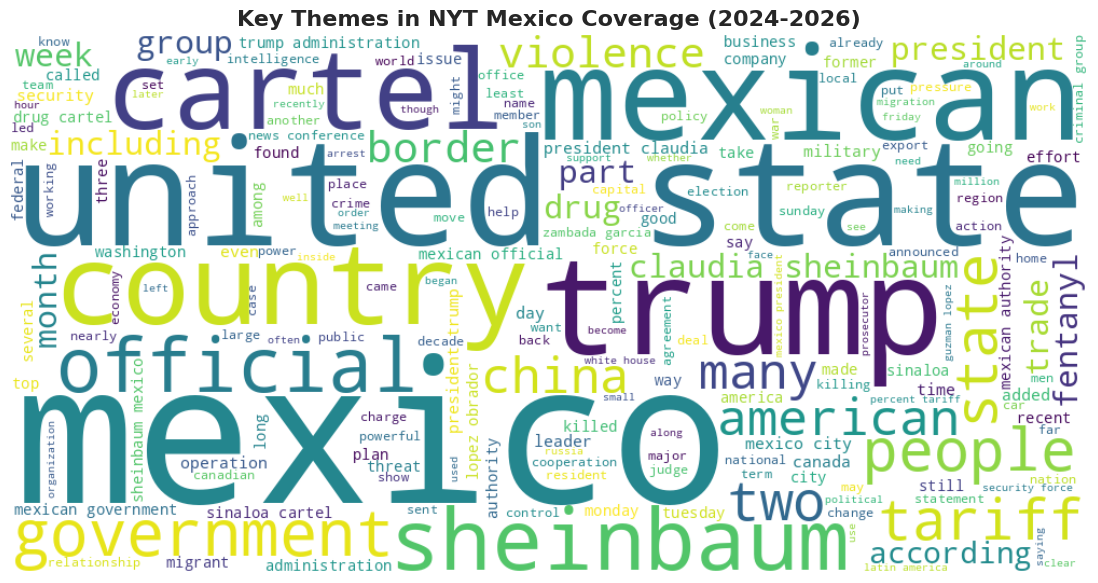

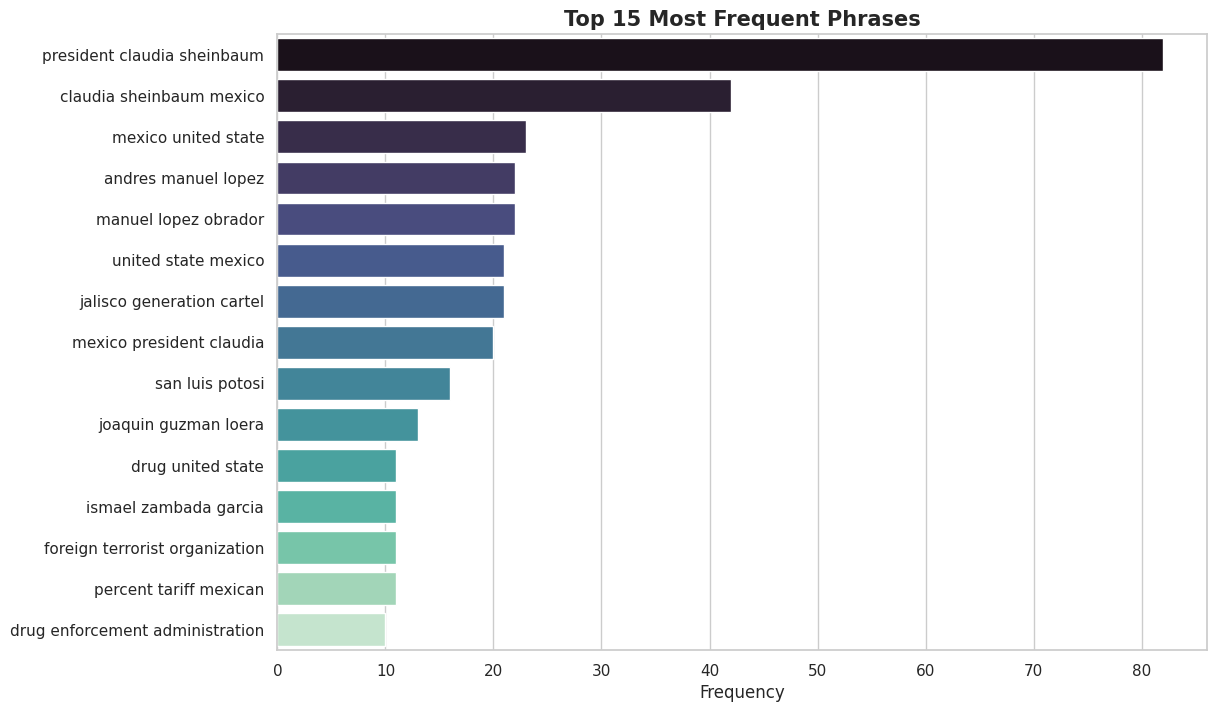

In [8]:
from wordcloud import WordCloud
from nltk.util import ngrams
from collections import Counter

# --- 1. Word Cloud (Collocations Enabled) ---
all_cleaned_text = " ".join(df['clean_text'])
wc = WordCloud(width=1000, height=500, background_color='white',
               colormap='viridis', collocations=True).generate(all_cleaned_text)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
# 'Thematic Word Cloud (Paired Phrases)'
plt.title('Key Themes in NYT Mexico Coverage (2024-2026)', fontsize=16, fontweight='bold')
plt.show()

# --- 2. Trigram Frequency Bar Chart ---
# Trigrams (3-word phrases) provide strong contextual insight
tokens = all_cleaned_text.split()
trigrams = list(ngrams(tokens, 3))
trigram_counts = Counter(trigrams).most_common(15)

# Prep for plotting
tri_labels = [" ".join(x[0]) for x in trigram_counts]
tri_values = [x[1] for x in trigram_counts]

plt.figure(figsize=(12, 8))
sns.barplot(x=tri_values, y=tri_labels, palette='mako', hue=tri_labels, legend=False)
# Top 15 Research Themes (Trigrams)
plt.title('Top 15 Most Frequent Phrases', fontsize=15, fontweight='bold')
plt.xlabel('Frequency')
plt.show()

### Time-Based Analysis

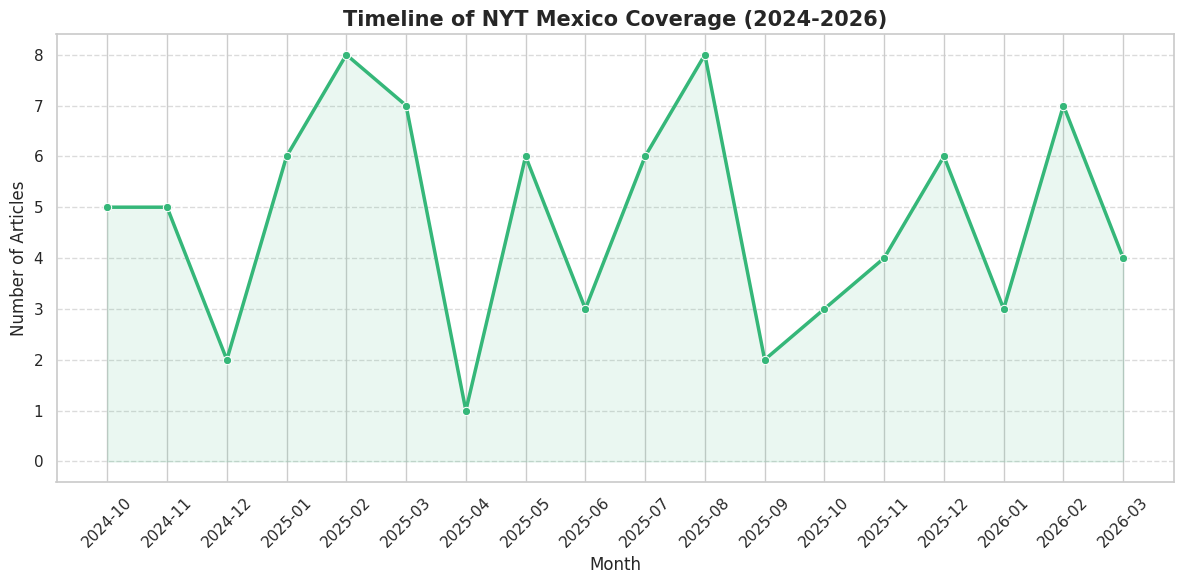

Articles per Month:
Month
2024-10    5
2024-11    5
2024-12    2
2025-01    6
2025-02    8
2025-03    7
2025-04    1
2025-05    6
2025-06    3
2025-07    6
2025-08    8
2025-09    2
2025-10    3
2025-11    4
2025-12    6
2026-01    3
2026-02    7
2026-03    4
Name: count, dtype: int64


In [9]:
# --- Time-Based Coverage Trend ---
# Grouping by the Month column we created earlier

# 1. Prepare the data
plt.figure(figsize=(12, 6))
monthly_counts = df['Month'].value_counts().sort_index()

# 2. Plotting the Trend
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o', color='#35b779', linewidth=2.5)
plt.fill_between(monthly_counts.index, monthly_counts.values, color='#35b779', alpha=0.1)

plt.title('Timeline of NYT Mexico Coverage (2024-2026)', fontweight='bold', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print the exact monthly counts
print("Articles per Month:")
print(monthly_counts)

## **Step 5**
# EDA Summary & Key Findings

## Dataset Overview
This dataset consists of 86 New York Times articles collected via the NYT Article Search API,
covering two interlinked topics: Claudia Sheinbaum's presidency and Mexico's security crisis.
Articles span from October 2024 to March 2026, coinciding with Sheinbaum's time in office.
Full article content was retrieved through an insitutional database. Location data was excluded as the NYT API does not reliably return geographic
information at the article level.

## Feature Engineering
Text features were extracted from the Full Article Content column:
- Average article length: ~977 words and ~40 sentences
- Average character count: ~6,009 characters per article
- Average word length: ~6.18 characters, consistent across articles indicating uniform journalistic style
- A minimum article length of 139 words (2 sentences) was noted — these short articles
  may represent news briefs and could influence NLP results

## Article Length Distribution
The distribution of word counts showed a bimodal pattern with peaks around 750 and 1,250 words,
suggesting two distinct article formats in the dataset — shorter news reports and longer
investigative or analytical pieces. No significant outliers were detected in the boxplot analysis.

## Temporal Coverage
Articles were distributed across 18 months with notable patterns:
- Peak coverage occurred in February 2025 and August 2025 (8 articles each),
  likely corresponding to major news events worth further investigation
- April 2025 saw a significant dip to just 1 article
- Coverage remained consistent at 3–8 articles per month throughout the dataset,
  reflecting sustained media interest in Mexico under Sheinbaum
- March 2026 shows 4 articles but the month is incomplete at time of collection

## Authorship
- 51 unique individual contributors were identified after splitting co-authored bylines
- Emiliano Rodríguez Mega was the most prolific contributor with 22 total article contributions,
  establishing him as the NYT's primary Mexico correspondent during this period
- James Wagner and Jack Nicas followed with 16 and 12 contributions respectively
- The high number of unique contributors (51 across 86 articles) indicates diverse
  journalistic perspectives in the dataset

## Key Themes
Word cloud and trigram analysis revealed the dominant themes in the dataset:
- **Cartel activity:** jalisco generation cartel, joaquin guzman loera, ismael zambada garcia,
  drug enforcement administration
- **U.S.-Mexico relations:** united state trump, foreign terrorist organization,
  percent tariff import, free trade agreement, fentanyl united state
- **Political and security landscape:** military, authority, violence, border, security
- Sheinbaum's daily press conferences ("mañaneras") appeared as a recurring theme
  via the trigram "daily news conference"

## Overall Observations
The dataset captures a politically and security-rich period in Mexican history. The overlap
between political and security themes reflects the reality that Sheinbaum's presidency has
been largely defined by cartel violence and U.S. pressure on drug trafficking and trade policy.
These interlinked themes provide a strong foundation for the NLP analysis steps that follow.

In [10]:
# Check for empty content
missing_content = df['Full Article Content'].isnull().sum()
print(f"Articles with missing content: {missing_content}")
print(f"Total rows in dataframe: {len(df)}")

Articles with missing content: 0
Total rows in dataframe: 86


# NLP Preprocessing Pipeline

### NLP Pipeline Architecture
To transform raw journalistic text into structured inputs for machine learning, I engineered a comprehensive preprocessing pipeline:

*   **Noise Reduction & Normalization:** Cleansed the corpus by stripping non-printable characters, punctuation, and digits. Applied custom stop-word filtering to remove standard English filler as well as journalistic boilerplate (e.g., "said", "New York Times").
*   **Data Masking:** Implemented regex-based redaction for sensitive entities (emails, phone numbers) to ensure data privacy and pipeline robustness.
*   **Advanced Tokenization:** Leveraged `spaCy` (`en_core_web_sm`) for efficient, context-aware tokenization.
*   **Semantic Vectorization:** Constructed a TF-IDF Document-Term Matrix to identify salient n-grams, and trained a custom Word2Vec (Skip-gram) embeddings model to capture deep semantic relationships across the corpus.

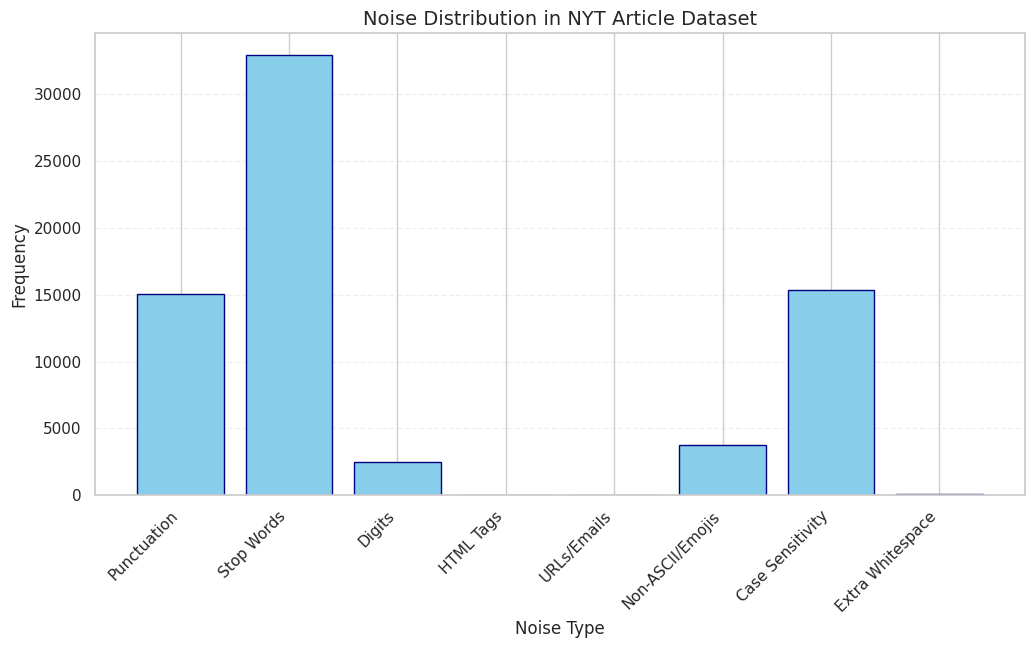

Summary of Noise Identification:
- Punctuation: 15,068
- Stop Words: 32,897
- Digits: 2,479
- HTML Tags: 0
- URLs/Emails: 9
- Non-ASCII/Emojis: 3,793
- Case Sensitivity: 15,320
- Extra Whitespace: 59


In [11]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

# Ensure we have the full stop words list for accurate counting
stop_words_list = set(stopwords.words('english'))

def analyze_noise_journalism(text):
    if not isinstance(text, str):
        return {k: 0 for k in ["Punctuation", "Stop Words", "Digits", "HTML Tags", "URLs/Emails", "Non-ASCII/Emojis", "Case Sensitivity", "Extra Whitespace"]}

    noise_counts = {
        "Punctuation": len(re.findall(r"[^\w\s]", text)),
        "Stop Words": len([word for word in text.split() if word.lower() in stop_words_list]),
        "Digits": len(re.findall(r"\d", text)),
        "HTML Tags": len(re.findall(r"<.*?>", text)),
        "URLs/Emails": len(re.findall(r"https?://\S+|\S+@\S+", text)),
        "Non-ASCII/Emojis": len(re.findall(r"[^\x00-\x7F]+", text)),
        "Case Sensitivity": len(re.findall(r"[A-Z]", text)), # Uppercase letters
        "Extra Whitespace": len(re.findall(r"\s{2,}", text))
    }
    return noise_counts

# 1. Apply analysis
df["noise_analysis"] = df["Full Article Content"].apply(analyze_noise_journalism)

# 2. Aggregate counts
noise_totals = {key: sum(d[key] for d in df["noise_analysis"]) for key in df["noise_analysis"].iloc[0]}

# 3. Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(noise_totals.keys(), noise_totals.values(), color='skyblue', edgecolor='navy')
plt.xlabel("Noise Type", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Noise Distribution in NYT Article Dataset", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


print("Summary of Noise Identification:")
for key, value in noise_totals.items():
    print(f"- {key}: {value:,}")

In [12]:
# --- Step 5.1: Text Cleaning ---

def text_cleaning(text):
    if not isinstance(text, str):
        return ""

    # 1. Remove HTML Tags & Non-printable characters
    text = re.sub(r"<.*?>", "", text)
    text = "".join(char for char in text if char.isprintable())

    # 2. Remove Punctuation, Special Characters, and Digits
    # Addresses punctuation and digit noise identified previously
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Remove Stop Words
    # Addresses stop word noise
    words = text.split()
    cleaned_words = [w for w in words if w.lower() not in stop_words_list]

    return " ".join(cleaned_words)

# Apply the cleaning
print("Executing Step 5.1: Text Cleaning")
df['pipeline_cleaned'] = df['Full Article Content'].apply(text_cleaning)

# Verification
display(df[['Full Article Content', 'pipeline_cleaned']].head(3))

Executing Step 5.1: Text Cleaning


,Full Article Content,pipeline_cleaned
0,The killings in the northwestern state of Sina...,killings northwestern state Sinaloa raise ques...
1,The stiff penalty was the potentially final st...,stiff penalty potentially final step stunning ...
2,Bodies dumped on the side of the road. Gun bat...,Bodies dumped side road Gun battles upscale ne...


In [13]:
# --- Step 5.2: Normalization ---
import unicodedata

def normalize_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercase (Addresses case sensitivity noise)
    text = text.lower()

    # 2. Remove Accents (e.g., López -> lopez)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    return text

# Apply normalization to the already cleaned text
print("Executing Step 5.2: Normalization")
df['pipeline_normalized'] = df['pipeline_cleaned'].apply(normalize_text)

# Verification
display(df[['pipeline_cleaned', 'pipeline_normalized']].head(3))

Executing Step 5.2: Normalization


,pipeline_cleaned,pipeline_normalized
0,killings northwestern state Sinaloa raise ques...,killings northwestern state sinaloa raise ques...
1,stiff penalty potentially final step stunning ...,stiff penalty potentially final step stunning ...
2,Bodies dumped side road Gun battles upscale ne...,bodies dumped side road gun battles upscale ne...


In [14]:
# --- Step 5.3: Data Masking ---
# Redacting sensitive information (Emails, etc.)

def mask_sensitive_data(text):
    if not isinstance(text, str):
        return ""

    # 1. Mask Email Addresses
    # Replaces things like 'reporter@nytimes.com' with '[EMAIL REDACTED]'
    text = re.sub(r"\S+@\S+", "[EMAIL REDACTED]", text)

    # 2. Optional: Mask Phone Numbers (if they appear in the text)
    # This looks for common phone patterns
    text = re.sub(r"\b\d{3}[-.]?\d{3}[-.]?\d{4}\b", "[PHONE REDACTED]", text)

    return text

# Apply the masking to the normalized column
print("Executing Step 5.3: Data Masking")
df['pipeline_masked'] = df['pipeline_normalized'].apply(mask_sensitive_data)

# Verification
# Note: Included to ensure pipeline robustness for sensitive data.
display(df[['pipeline_normalized', 'pipeline_masked']].head(3))

Executing Step 5.3: Data Masking


,pipeline_normalized,pipeline_masked
0,killings northwestern state sinaloa raise ques...,killings northwestern state sinaloa raise ques...
1,stiff penalty potentially final step stunning ...,stiff penalty potentially final step stunning ...
2,bodies dumped side road gun battles upscale ne...,bodies dumped side road gun battles upscale ne...


In [15]:
test_string = "Contact the author at author@example.com or call 555-123-4567"
masked_test = mask_sensitive_data(test_string)

print(f"Original: {test_string}")
print(f"Masked:   {masked_test}")

Original: Contact the author at author@example.com or call 555-123-4567
Masked:   Contact the author at [EMAIL REDACTED] or call [PHONE REDACTED]


In [16]:
# --- Step 5.4: Word Tokenization ---
# Use spaCy for word tokenization

import spacy

# Load the English model
nlp = spacy.load("en_core_web_sm")

def spacy_tokenize(text):
    if not isinstance(text, str):
        return []

    # Process the text
    doc = nlp(text)

    # Extract just the text of each token
    tokens = [token.text for token in doc if not token.is_space]

    return tokens

# Apply tokenization
print("Executing Step 5.4: Word Tokenization")
df['pipeline_tokenized'] = df['pipeline_masked'].apply(spacy_tokenize)

# Final Verification for Step 5
display(df[['pipeline_masked', 'pipeline_tokenized']].head(3))

Executing Step 5.4: Word Tokenization


,pipeline_masked,pipeline_tokenized
0,killings northwestern state sinaloa raise ques...,"[killings, northwestern, state, sinaloa, raise..."
1,stiff penalty potentially final step stunning ...,"[stiff, penalty, potentially, final, step, stu..."
2,bodies dumped side road gun battles upscale ne...,"[bodies, dumped, side, road, gun, battles, ups..."


In [17]:
# --- Step 5.5: Feature Extraction - TF-IDF ---
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. Prepare data: TfidfVectorizer expects a string, so we join our tokens
# We use the cleaned/normalized/masked tokens we created in Step 5.4
tfidf_input = df['pipeline_tokenized'].apply(lambda x: " ".join(x))

# 2. Initialize the Vectorizer
vectorizer = TfidfVectorizer(
    lowercase=False,               # We already lowercased in Step 5.2
    max_features=20,               # Top 20 most important words
    ngram_range=(1,2),             # Look for single words and phrases (like 'mexico city')
    token_pattern=r'\b\w+\b'
)

# 3. Fit and transform the text into a document-term matrix
dtm_matrix = vectorizer.fit_transform(tfidf_input)

# 4. Convert to a DataFrame for display
tfidf_df = pd.DataFrame(dtm_matrix.toarray(), columns=vectorizer.get_feature_names_out())

print("TF-IDF Document-Term Matrix (Top 20 Features):")
display(tfidf_df.head())

TF-IDF Document-Term Matrix (Top 20 Features):


,also,cartel,cartels,government,mexican,mexico,mexicos,mr,mr trump,ms,officials,president,said,sheinbaum,states,trump,united,united states,us,would
0,0.051558,0.757690,0.068955,0.051558,0.047003,0.091867,0.273313,0.248973,0.0,0.113270,0.052774,0.141008,0.359113,0.142642,0.099589,0.0,0.160184,0.109325,0.156486,0.108048
1,0.090328,0.221242,0.120808,0.180657,0.123521,0.321896,0.143651,0.785149,0.0,0.049612,0.184917,0.123521,0.235934,0.083301,0.043619,0.0,0.046773,0.047884,0.137079,0.000000
2,0.000000,0.543997,0.000000,0.266523,0.040496,0.118723,0.047095,0.171604,0.0,0.146384,0.090936,0.080991,0.580121,0.081930,0.171604,0.0,0.138008,0.094190,0.359525,0.139635
3,0.000000,0.324696,0.354596,0.088377,0.161138,0.157472,0.187398,0.512127,0.0,0.388321,0.090462,0.161138,0.230838,0.407511,0.000000,0.0,0.000000,0.000000,0.000000,0.092604
4,0.000000,0.146460,0.000000,0.000000,0.163540,0.426185,0.126794,0.057751,0.0,0.262740,0.061207,0.109027,0.780930,0.220579,0.000000,0.0,0.000000,0.000000,0.060497,0.062657


In [18]:
!pip install -q gensim

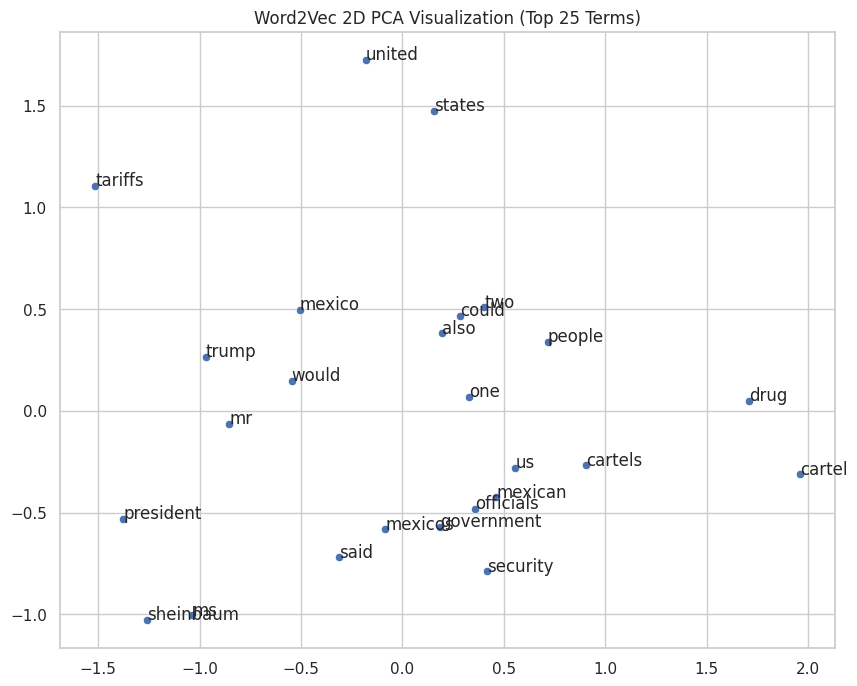

In [19]:
# --- Step 5.6: Feature Extraction - Word2Vec ---
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Define the parameters
word2vec_params = {
    "vector_size": 50,  # 50-dimensional vectors
    "window": 3,        # Context window
    "min_count": 1,     # Include all words
    "workers": 4,
    "sg": 1,            # Skip-gram model
    "epochs": 10
}

# 2. Train the model on tokenized articles
model = Word2Vec(sentences=df['pipeline_tokenized'], **word2vec_params)

# 3. Visualization: 2D PCA Plot
words = list(model.wv.index_to_key)[:25] # top 25 words
word_vectors = model.wv[words]

pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# Create the plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=word_vectors_2d[:, 0], y=word_vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=12)

plt.title("Word2Vec 2D PCA Visualization (Top 25 Terms)")
plt.show()

In [20]:
!pip install -q squarify

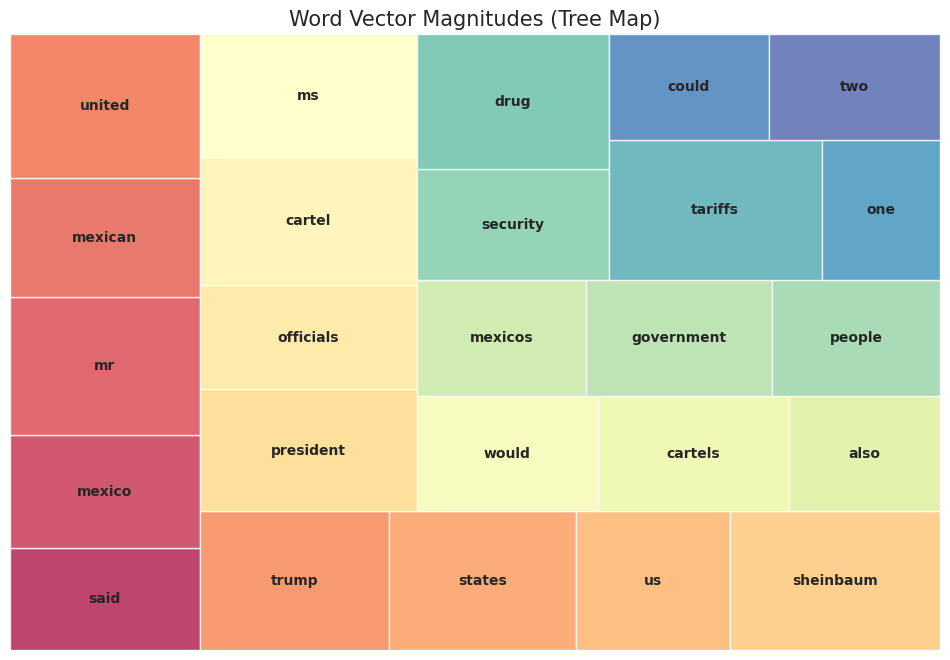

In [21]:
# --- Step 5.7: Treemap of Word Vector Magnitudes ---

# 1. Install squarify if not already present
import squarify
import numpy as np

# 2. Get the top 25 words from your trained model
# Using 'index_to_key[:25]' ensures we only look at the most frequent/important words
words = list(model.wv.index_to_key)[:25]

# 3. Compute the "strength" (magnitude) of these word vectors
word_magnitudes = [np.linalg.norm(model.wv[word]) for word in words]

# 4. Create the Treemap visualization
plt.figure(figsize=(12, 8))

# We use the magnitudes for the box sizes and the word list for labels
squarify.plot(sizes=word_magnitudes, label=words, alpha=0.8,
              color=sns.color_palette("Spectral", len(words)),
              text_kwargs={'fontsize':10, 'weight':'bold'})

plt.title("Word Vector Magnitudes (Tree Map)", fontsize=15)
plt.axis("off")  # Hide axes for a cleaner visualization
plt.show()

Generating vectors for all articles...


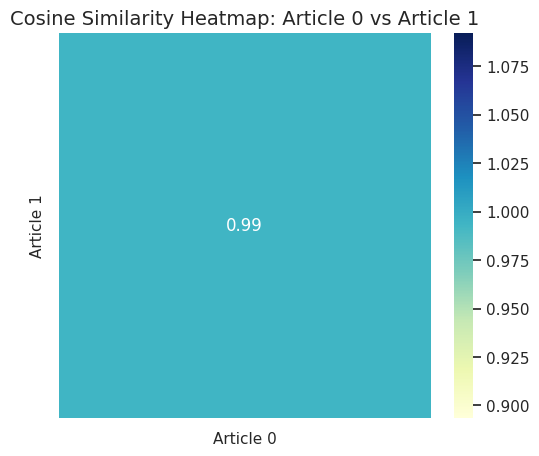


Similarity Score: 0.9929
Interpretation: 1.0 is identical, 0.0 is completely different.


In [22]:
# --- Step 5.8: Sentence (Article) Vectors & Similarity ---
from sklearn.metrics.pairwise import cosine_similarity

# 1. Function to calculate the average vector for an entire article
def get_article_vector(tokens, model):
    # Only use words that the Word2Vec model actually learned
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    # If the article has words, average them; otherwise, return zeros
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# 2. Apply this to your entire dataset
# This creates a 'meaning vector' for every single article
print("Generating vectors for all articles...")
df['article_vector'] = df['pipeline_tokenized'].apply(lambda x: get_article_vector(x, model))

# 3. Compare two specific articles (e.g., the first two in your list)
# We reshape them because the math function expects a specific format
vec_a = df['article_vector'].iloc[0].reshape(1, -1)
vec_b = df['article_vector'].iloc[1].reshape(1, -1)

# Compute Similarity (Result is between 0 and 1)
cos_sim = cosine_similarity(vec_a, vec_b)

# 4. Plot the Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cos_sim, annot=True, cmap="YlGnBu",
            xticklabels=["Article 0"], yticklabels=["Article 1"])

plt.title("Cosine Similarity Heatmap: Article 0 vs Article 1", fontsize=14)
plt.show()

print(f"\nSimilarity Score: {cos_sim[0][0]:.4f}")
print("Interpretation: 1.0 is identical, 0.0 is completely different.")

In [23]:
print("Article 0 snippet:", df['Full Article Content'].iloc[0][:200])
print("\nArticle 1 snippet:", df['Full Article Content'].iloc[1][:200])

Article 0 snippet: The killings in the northwestern state of Sinaloa raise questions on whether Mexico’s new president, Claudia Sheinbaum, is taking a tougher approach to cartels.
Mexican soldiers killed 19 suspected ca

Article 1 snippet: The stiff penalty was the potentially final step in the stunning downfall of the former official, Genaro García Luna, who has gone from the heights of power to imprisonment.
Genaro García Luna, who on


# Sentiment Analysis

### Sentiment Analysis Strategy
To accurately capture the emotional tone of the reporting, I implemented a comparative, multi-lexicon approach followed by time-series smoothing:

*   **Multi-Lexicon Sentiment Scoring:** Extracted sentiment polarity using three distinct NLP lexicons (VADER, TextBlob, and AFINN). This comparative approach ensures a more robust and objective evaluation of the underlying journalistic tone.
*   **Longitudinal Trend Analysis:** Engineered time-series aggregations (monthly resampling) to reduce localized noise and visualize macro-level shifts in media sentiment over the 18-month reporting period.

In [24]:
!pip install -q vaderSentiment textblob afinn

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Calculating sentiment scores on cleaned and masked text...


/tmp/ipykernel_10328/2198008751.py:36: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_trend = df.set_index('Publication Date').resample('M').mean(numeric_only=True)


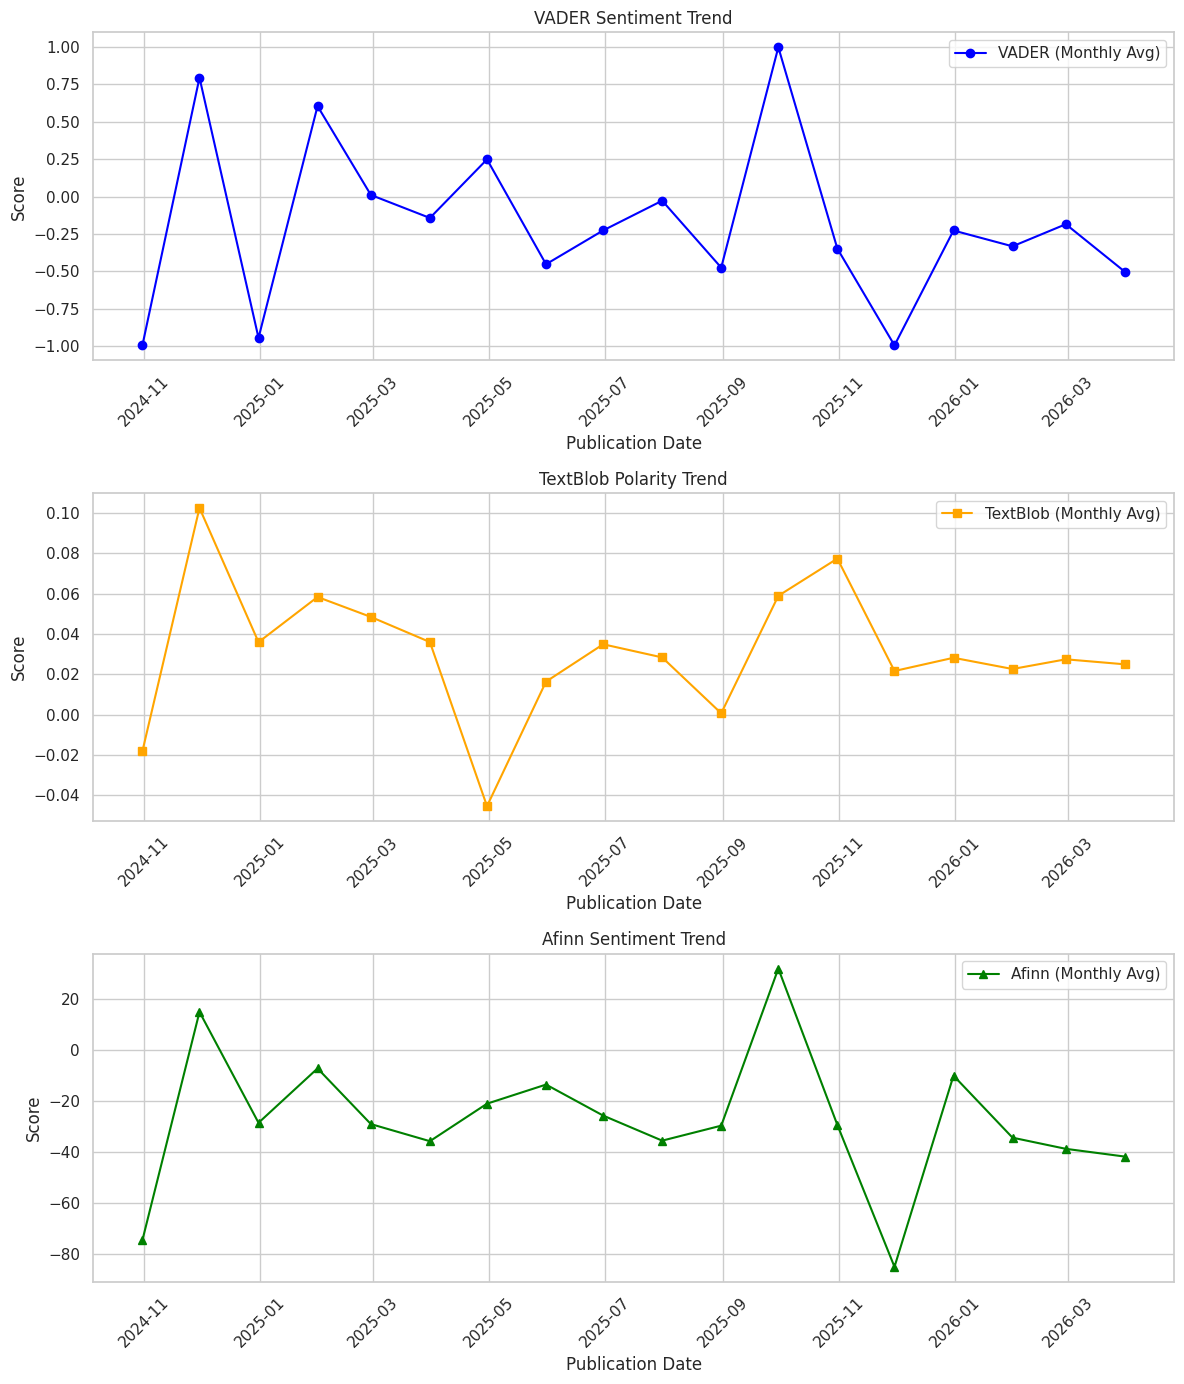

Calculated scores:


,vader_score,textblob_score,afinn_score
0,-0.9988,-0.006883,-72.0
1,-0.9855,0.074603,-55.0
2,-0.9993,-0.005478,-103.0
3,-0.9980,-0.076302,-87.0
4,-0.9974,-0.077010,-56.0


In [25]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from afinn import Afinn
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Setup
nltk.download('vader_lexicon')
vader = SentimentIntensityAnalyzer()
afinn = Afinn()

def analyze_sentiment(text):
    text_str = str(text) if pd.notnull(text) else ""
    return {
        "vader_score": vader.polarity_scores(text_str)['compound'],
        "textblob_score": TextBlob(text_str).sentiment.polarity,
        "afinn_score": afinn.score(text_str)
    }

# 2. Calculate scores using the 'pipeline_masked' column for consistency
print("Calculating sentiment scores on cleaned and masked text...")
sentiment_results = df['pipeline_masked'].apply(analyze_sentiment)
df_scores = pd.json_normalize(sentiment_results)

# 3. Clean up duplicates and Merge
cols_to_drop = ['vader_score', 'textblob_score', 'afinn_score', 'sentiment_label']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = pd.concat([df.reset_index(drop=True), df_scores], axis=1)
df['sentiment_label'] = df['vader_score'].apply(lambda x: 1 if x > 0 else 0)

# 4. Prepare data for time-series trend plotting
df['Publication Date'] = pd.to_datetime(df['Publication Date'])
# We create a new dataframe that is 'Resampled' by Month ('M') or Week ('W')
# This averages the scores to reduce variance and smooth the trend line
df_trend = df.set_index('Publication Date').resample('M').mean(numeric_only=True)

# 5. Plotting the Smoothed Data
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Panel 1: VADER (Smoothed)
axes[0].plot(df_trend.index, df_trend["vader_score"], marker='o', color='blue', label="VADER (Monthly Avg)")
axes[0].set_title("VADER Sentiment Trend")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("Publication Date") # Independent label
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Panel 2: TextBlob (Smoothed)
axes[1].plot(df_trend.index, df_trend["textblob_score"], marker='s', color='orange', label="TextBlob (Monthly Avg)")
axes[1].set_title("TextBlob Polarity Trend")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Publication Date") # Independent label
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Panel 3: Afinn (Smoothed)
axes[2].plot(df_trend.index, df_trend["afinn_score"], marker='^', color='green', label="Afinn (Monthly Avg)")
axes[2].set_title("Afinn Sentiment Trend")
axes[2].set_ylabel("Score")
axes[2].set_xlabel("Publication Date") # Independent label
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Calculated scores:")
display(df[['vader_score', 'textblob_score', 'afinn_score']].head())

# Sentiment Classification Model

### Classification Model Architecture
To take this from exploratory analysis to predictive machine learning, I built an end-to-end classification pipeline:

*   **Target Generation (Weak Supervision):** Leveraged VADER compound sentiment scores to generate binary target labels (Positive=1, Negative=0), enabling a supervised learning approach.
*   **XGBoost Classifier:** Trained an Extreme Gradient Boosting (XGBoost) model utilizing the custom Word2Vec document embeddings as the primary feature space.
*   **Model Diagnostics:** Evaluated predictive performance and class separations using standard classification metrics (accuracy, F1-score, and confusion matrix).
*   **Inference Pipeline:** Engineered an interactive prediction function that simulates deployment, passing raw, unseen text through the complete preprocessing, vectorization, and model inference pipeline to return a sentiment label and confidence threshold.

Building Word2Vec Vocabulary and Training...
Vectorizing headlines into document embeddings...
Training Custom XGBoost Classifier...

FINAL MODEL EVALUATION
Accuracy Score: 0.7222

Confusion Matrix:
[[7 2]
 [3 6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.78      0.74         9
           1       0.75      0.67      0.71         9

    accuracy                           0.72        18
   macro avg       0.72      0.72      0.72        18
weighted avg       0.73      0.72      0.72        18



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:21:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_10328/417848863.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


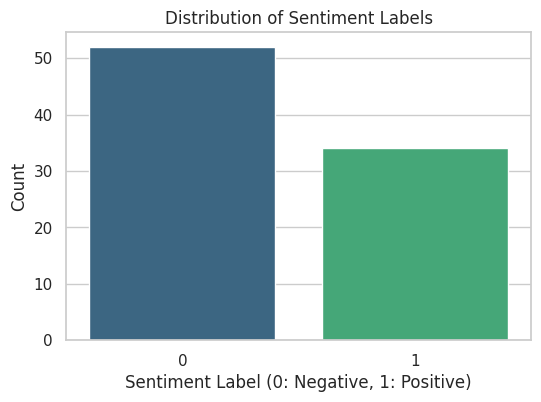

Sentiment Label Value Counts:
sentiment_label
0    52
1    34
Name: count, dtype: int64


In [29]:
import numpy as np
import pickle
from gensim.models import Word2Vec
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Part 1: Feature Extraction using Word2Vec ---
print("Building Word2Vec Vocabulary and Training...")

# Set hyperparameters for Word2Vec model
# We use the 'pipeline_tokenized' column which is a list of lists
w2v_model = Word2Vec(sentences=df['pipeline_tokenized'],
                     vector_size=50,  # Increased vector size for better semantic representation
                     window=5,
                     min_count=1,
                     workers=4,
                     epochs=50) # Increased epochs for more robust embeddings

def get_mean_vector(model, words):
    """
    Iterates through tokens and averages the vectors of words found in the model vocabulary.
    """
    # Filter words that are actually in the Word2Vec vocabulary
    valid_words = [word for word in words if word in model.wv.index_to_key]

    if len(valid_words) >= 1:
        return np.mean(model.wv[valid_words], axis=0)
    else:
        # If no words match, return a vector of zeros
        return np.zeros(model.vector_size)

# Generate the feature matrix X
print("Vectorizing headlines into document embeddings...")
X = np.array([get_mean_vector(w2v_model, tokens) for tokens in df['pipeline_tokenized']])
y = df['sentiment_label']

# --- Part 2: Building the XGBoost Classifier ---
# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training Custom XGBoost Classifier...")
# Calculate class weights for imbalance handling
# This gives more weight to the minority class (positive sentiment, label 1)
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

# Initialize and train the XGBoost model with scale_pos_weight
xgb_clf = XGBClassifier(n_estimators=100,
                        learning_rate=0.1,
                        max_depth=5,
                        use_label_encoder=False,
                        eval_metric='logloss',
                        scale_pos_weight=scale_pos_weight_value) # Added class weight

xgb_clf.fit(X_train, y_train)

# --- Part 3: Model Persistence (Saving) ---
w2v_model.save("custom_word2vec.model")
with open("sentiment_xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_clf, f)

# --- Part 4: Evaluation ---
y_pred = xgb_clf.predict(X_test)
print("\n" + "="*30)
print("FINAL MODEL EVALUATION")
print("="*30)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- Part 5: Analyze Sentiment Label Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Label (0: Negative, 1: Positive)')
plt.ylabel('Count')
plt.show()

print("Sentiment Label Value Counts:")
print(y.value_counts())

In [27]:
# --- Part 5: Interactive Testing System ---
def predict_user_input():
    # Load the trained models
    loaded_w2v = Word2Vec.load("custom_word2vec.model")
    with open("sentiment_xgb_model.pkl", "rb") as f:
        loaded_xgb = pickle.load(f)

    print("\n" + "*"*50)
    print("NYT SENTIMENT PREDICTION SYSTEM")
    print("*"*50)

    user_text = input("Enter a headline or article snippet to analyze: ")

    if user_text:
        # Apply full preprocessing pipeline
        clean_1 = text_cleaning(user_text)      # Step 5.1
        norm_2  = normalize_text(clean_1)       # Step 5.2
        mask_3  = mask_sensitive_data(norm_2)   # Step 5.3
        tokens  = spacy_tokenize(mask_3)        # Step 5.4

        # Vectorize using the mean vector function
        vector = get_mean_vector(loaded_w2v, tokens).reshape(1, -1)

        # Predict class and probability
        prediction = loaded_xgb.predict(vector)[0]
        probability = loaded_xgb.predict_proba(vector)[0]

        label = "POSITIVE (1)" if prediction == 1 else "NEGATIVE (0)"
        confidence = probability[1] if prediction == 1 else probability[0]

        print(f"\nProcessed Tokens: {tokens}")
        print(f"Predicted Sentiment: {label}")
        print(f"Confidence Score: {confidence:.4f}")

# Start the interactive test
predict_user_input()


**************************************************
NYT SENTIMENT PREDICTION SYSTEM
**************************************************
Enter a headline or article snippet to analyze: Protesters rage against Mexico’s Government Over Corruption and Violence

Processed Tokens: ['protesters', 'rage', 'mexicos', 'government', 'corruption', 'violence']
Predicted Sentiment: NEGATIVE (0)
Confidence Score: 0.8307
